# 06 · Figures on quality-controlled fluxes

Rebuilds the notebook 03 and notebook 04 figures, but on the
**quality-controlled** fluxes from the flux processing chain
([notebook 05](05_flux_processing_chain.ipynb)) instead of the raw Level-1
fluxes. This shows whether the time-lag patterns seen in the raw budget survive
L2 to L3.3 quality control and USTAR filtering.

The chain produced one USTAR-filtered flux per scenario (CUT_16 / CUT_50 /
CUT_84); these figures use a single scenario, `USTAR_SCENARIO`, set in the
configuration. Re-run with a different value to compare scenarios.

Two figure sets are produced, mirroring the earlier notebooks:

- **Like notebook 03:** per analyzer and gas, the QC flux (top), the time lag
  used (middle), and a histogram of that lag (bottom), with the five variants as
  columns. Saved as `figures/06_{scenario}_{analyzer}_{gas}.png`.
- **Like notebook 04:** per analyzer and gas, the cumulative QC flux over the
  paired common samples (all, daytime, nighttime). Saved as
  `figures/06_cumulative_{scenario}_{analyzer}_{gas}.png`.

Inputs:
- `data/05-flux_processing_chain_parquet/` for the QC fluxes (and `SW_IN_POT` /
  `DAYTIME` / `NIGHTTIME`, computed by the chain).
- `data/02-…_subsets/` and `data/01-pwb_tlag_summary_parquet/` for the time lag
  (the chain output does not carry it), exactly as in notebook 03.

## Imports

In [1]:
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from diive.core.io.files import load_parquet

NB_START = datetime.now()  # notebook start time (reported in the last cell)

## Configuration

`USTAR_SCENARIO` selects which of the three USTAR-filtered fluxes to plot. The QC
flux column in each `*_fpc.parquet` follows the chain's naming convention,
`{gas}_L3.1_L3.3_{scenario}_QCF` (the `L3.1` segment is the storage step, a
pass-through here). The variant / gas registry matches notebook 03: the lag for
variants `*-1` to `*-4` is the EddyPro time lag used, while the PWB column
(`*-5`) uses its detected lag.

In [2]:
FPCDIR = Path("../data/05-flux_processing_chain_parquet")              # QC fluxes
SUBSETDIR = Path("../data/02-eddypro_fluxes_level-1_parquet_subsets")  # lag, *-1..*-4
PWBDIR = Path("../data/01-pwb_tlag_summary_parquet")                   # lag, *-5
FIGDIR = Path("../figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

YEAR = 2021
USTAR_SCENARIO = "CUT_50"  # one of CUT_16 / CUT_50 / CUT_84

FIGSIZE = (16, 9)
DPI = 300

# Columns = the four EddyPro-lag variants plus the PWB variant as the last column.
ANALYZERS = {
    "QCL": {"flux_variants": ["QCL-1", "QCL-2", "QCL-3", "QCL-4"], "pwb": "QCL-5"},
    "LGR": {"flux_variants": ["LGR-1", "LGR-2", "LGR-3", "LGR-4"], "pwb": "LGR-5"},
}
# Per gas: the flux variable, the EddyPro time-lag-used variable, and the PWB
# detected-lag column.
GASES = {
    "N2O": {"flux": "FN2O", "lag": "N2O_TLAG_USED", "pwb_lag": "n2o_tlag_final_pf_s"},
    "CH4": {"flux": "FCH4", "lag": "CH4_TLAG_USED", "pwb_lag": "ch4_tlag_final_pf_s"},
}

FLUX_COLOR = "#1b9e77"  # teal
LAG_COLOR = "#d95f02"   # orange
HIST_COLOR = "#6c5ce7"  # indigo
BIN_S = 0.05            # lag histogram bin width (s); EddyPro tlag grid
PCTL = (1, 99)         # robust flux y-range percentiles


def qc_col(fluxvar, scenario):
    """Name of the USTAR-filtered, QCF-accepted flux column in the fpc output."""
    return f"{fluxvar}_L3.1_L3.3_{scenario}_QCF"


print(f"Plotting USTAR scenario: {USTAR_SCENARIO}")

Plotting USTAR scenario: CUT_50


## Load the QC fluxes and the time lag

For each variant and gas, the QC flux is pulled from its `*_fpc.parquet` (the
single `USTAR_SCENARIO` column). The time lag is loaded separately, the same way
as notebook 03: from the column subsets for `*-1` to `*-4`, and from the PWB tlag
summaries for `*-5`. `SW_IN_POT` (for the daytime / nighttime split) is taken
from the chain output and is identical across variants.

In [3]:
flux_codes = [c for a in ANALYZERS.values() for c in a["flux_variants"]]
pwb_codes = [a["pwb"] for a in ANALYZERS.values()]
all_codes = flux_codes + pwb_codes

# QC flux per (code, gas-name): one Series for the chosen USTAR scenario.
qcflux = {}
swin = {}  # SW_IN_POT per code (identical across gases; read once per code)
for code in all_codes:
    for gas, v in GASES.items():
        df = load_parquet(filepath=str(FPCDIR / f"{code}_{v['flux']}_fpc.parquet"))
        df = df.loc[df.index.year == YEAR]
        qcflux[(code, gas)] = df[qc_col(v["flux"], USTAR_SCENARIO)]
        if code not in swin:
            swin[code] = df["SW_IN_POT"]

# Time lag: subsets for *-1..*-4, PWB summaries for *-5 (as in notebook 03).
lag_subset = {c: load_parquet(filepath=str(SUBSETDIR / f"{c}.parquet")) for c in flux_codes}
pwb_data = {c: load_parquet(filepath=str(PWBDIR / f"{c}_pwb_tlag.parquet")) for c in pwb_codes}
lag_subset = {c: d.loc[d.index.year == YEAR] for c, d in lag_subset.items()}
pwb_data = {c: d.loc[d.index.year == YEAR] for c, d in pwb_data.items()}

for (code, gas), s in qcflux.items():
    if gas == "N2O":
        print(f"{code}: {int(s.notna().sum())} valid QC {gas} ({USTAR_SCENARIO})")

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-1_FN2O_fpc.parquet (0.043 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-1_FCH4_fpc.parquet (0.010 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-2_FN2O_fpc.parquet (0.009 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-2_FCH4_fpc.parquet (0.010 seconds).

> Loaded .parquet file ..\data\05-flux_processing_chain_parquet\QCL-3_FN2O_fpc.parquet (0.009 seconds).

...

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-3.parquet (0.003 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-4.parquet (0.003 seconds).

> Loaded .parquet file ..\data\01-pwb_tlag_summary_parquet\QCL-5_pwb_tlag.parquet (0.013 seconds).

> Loaded .parquet file ..\data\01-pwb_tlag_summary_parquet\LGR-5_pwb_tlag.parquet (0.007 seconds).

QCL-1: 6270 valid QC N2O (CUT_50)
QCL-2: 6206 valid QC N2O (CUT_50)
QCL-3: 5468 valid QC N2O (CUT_50)
QCL-4: 5314 valid QC N2O (CUT_50)
LGR-1: 5067 valid QC N2O (CUT_50)
LGR-2: 5029 valid QC N2O (CUT_50)
LGR-3: 4831 valid QC N2O (CUT_50)
LGR-4: 4362 valid QC N2O (CUT_50)
QCL-5: 5313 valid QC N2O (CUT_50)
LGR-5: 4339 valid QC N2O (CUT_50)


## Figures like notebook 03: QC flux, time lag, lag histogram

One figure per analyzer and gas. Three rows (QC flux over time, time lag used over
time, lag histogram) with the five variants as columns. The flux is now the
USTAR-filtered, quality-controlled series, so it has more gaps than the raw flux
in notebook 03; the lag rows are unchanged. The constant-lag variant (`*-4`)
shows its single lag value as a note instead of a histogram, and the PWB column
(`*-5`) uses its detected lag.

Saved ..\figures\06_cut_50_qcl_n2o.png


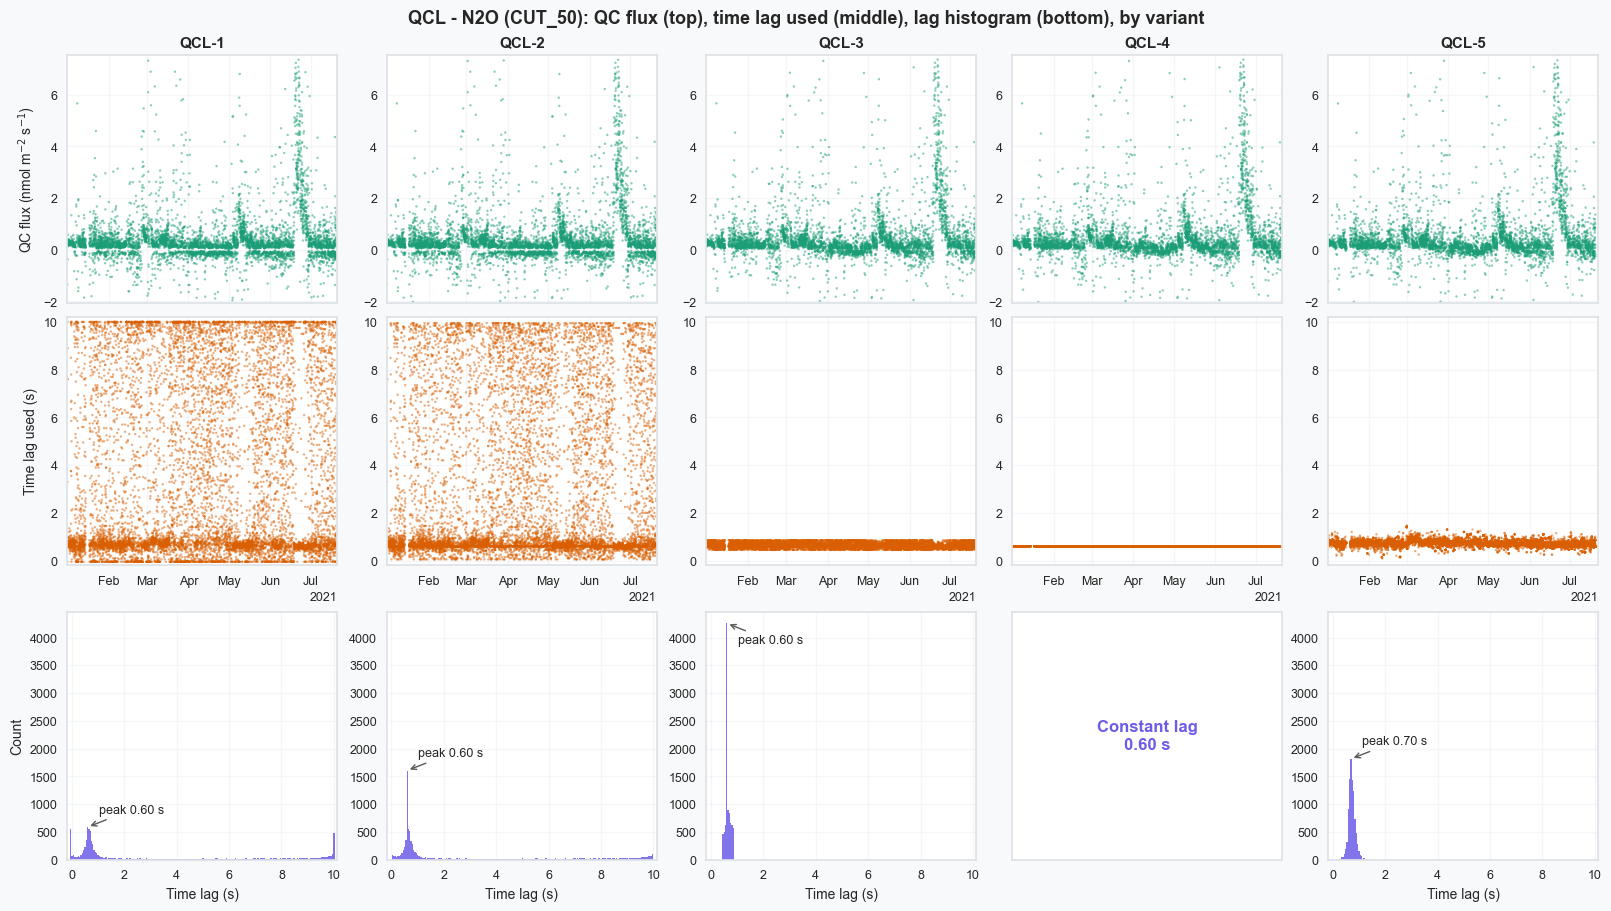

Saved ..\figures\06_cut_50_qcl_ch4.png


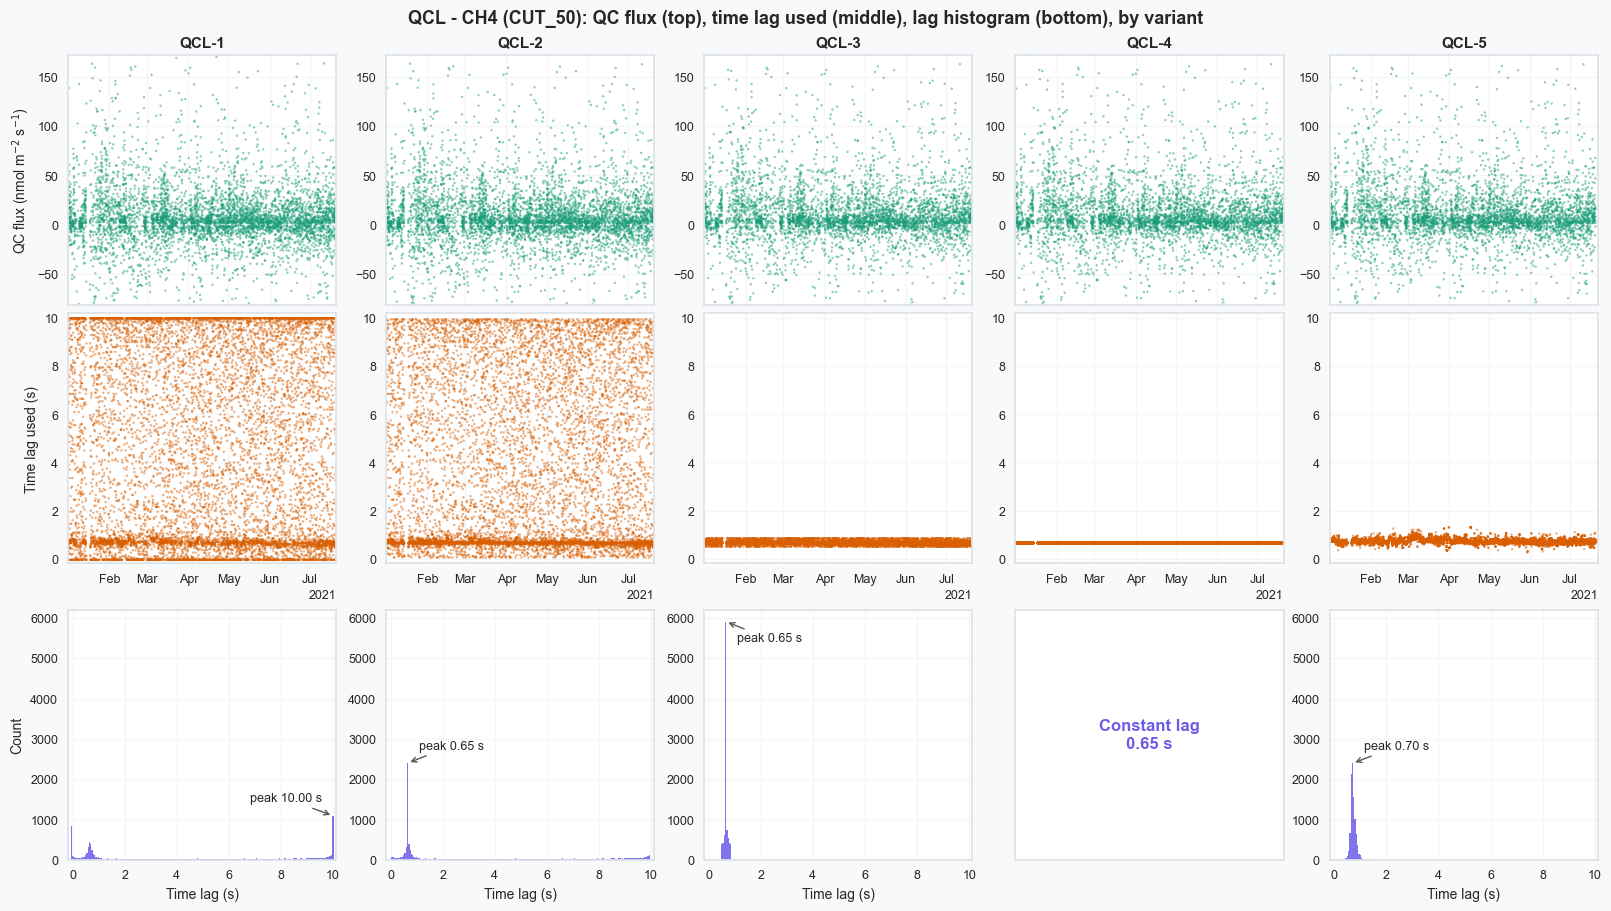

Saved ..\figures\06_cut_50_lgr_n2o.png


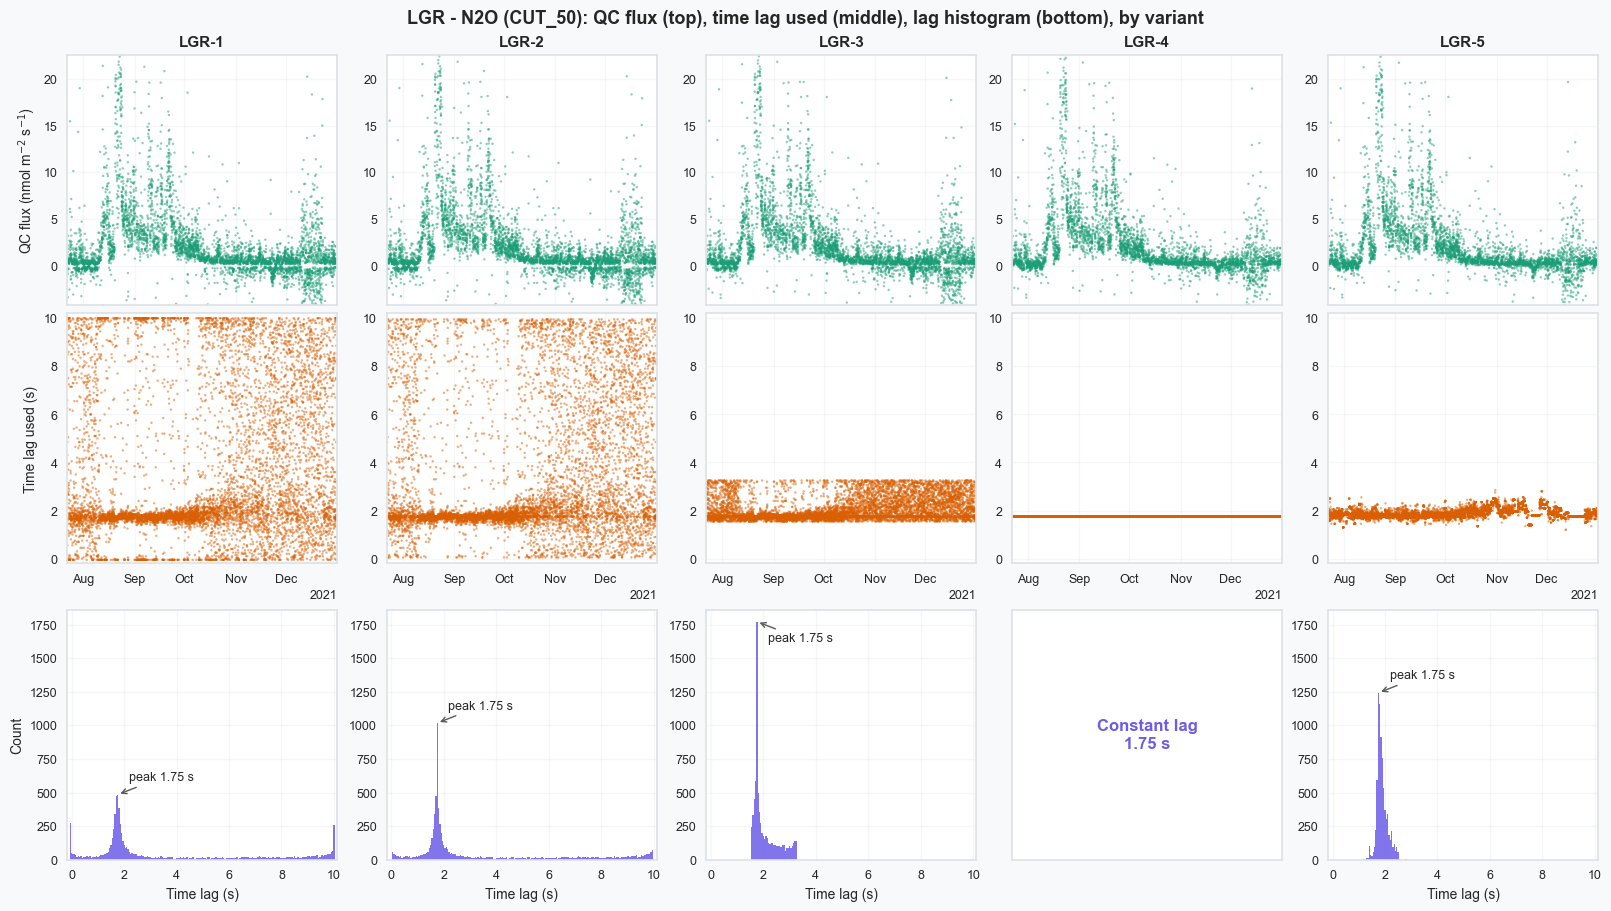

Saved ..\figures\06_cut_50_lgr_ch4.png


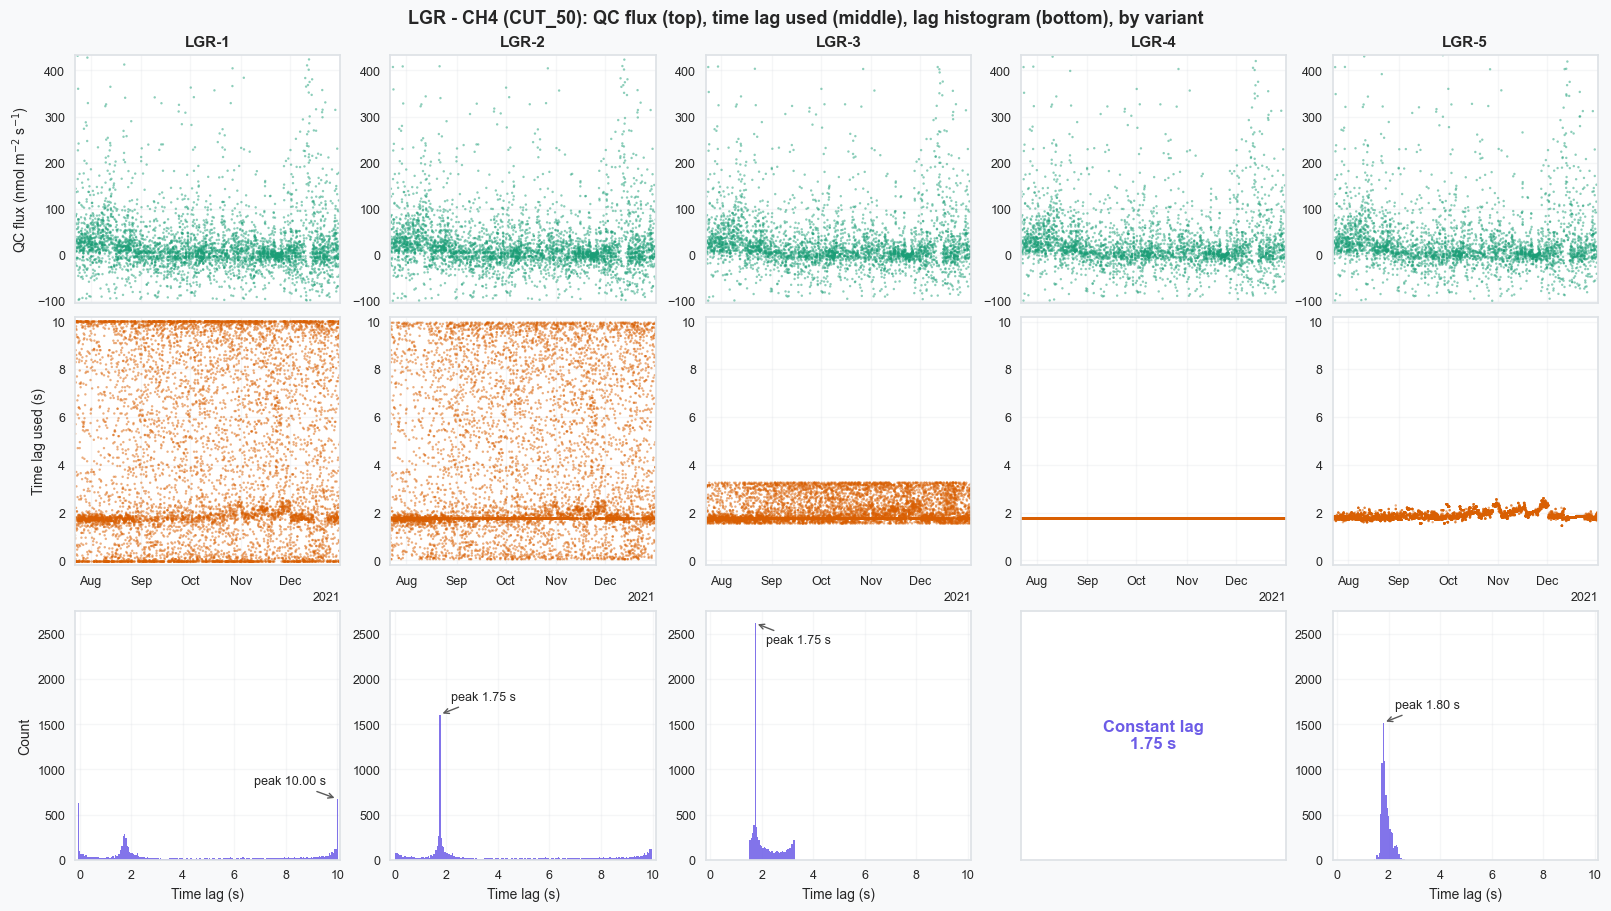

In [4]:
def robust_ylim(values, pctl=PCTL, pad_frac=0.05):
    """Percentile-based y-limits with a small symmetric pad."""
    lo, hi = np.nanpercentile(values, pctl)
    pad = pad_frac * (hi - lo)
    return lo - pad, hi + pad


LAG_YLIM = (-0.2, 10.2)  # full 0 to 10 s search window with a small pad

for analyzer, info in ANALYZERS.items():
    flux_variants = info["flux_variants"]
    pwb_code = info["pwb"]
    columns = flux_variants + [pwb_code]  # PWB is the last column

    for gas, v in GASES.items():
        lagvar, pwb_lag = v["lag"], v["pwb_lag"]

        # The lag series per column: PWB uses its detected lag, the others use
        # the EddyPro time lag used.
        def lag_of(code):
            return pwb_data[code][pwb_lag] if code == pwb_code else lag_subset[code][lagvar]

        # Robust flux range across all columns' QC flux.
        flux_vals = np.concatenate(
            [qcflux[(c, gas)].to_numpy().ravel() for c in columns])
        flux_ylim = robust_ylim(flux_vals)

        # Common lag range across all columns, for the shared histogram bins.
        all_lag = np.concatenate([lag_of(c).to_numpy().ravel() for c in columns])
        lag_lo, lag_hi = np.nanmin(all_lag), np.nanmax(all_lag)
        lo_k = int(np.floor(lag_lo / BIN_S))
        hi_k = int(np.ceil(lag_hi / BIN_S))
        bins = (np.arange(lo_k, hi_k + 2) - 0.5) * BIN_S

        # Shared histogram count axis: tallest peak across all columns that show
        # a histogram (every column except the constant-lag *-4 note).
        hist_codes = [c for c in columns if not c.endswith("-4")]
        peak_count = max(
            int(np.histogram(lag_of(c).dropna(), bins=bins)[0].max()) for c in hist_codes)
        hist_ylim = (0, peak_count * 1.05)
        hist_xlim = (bins[0] - 0.1, bins[-1] + 0.1)

        fig, axes = plt.subplots(nrows=3, ncols=len(columns),
                                 figsize=FIGSIZE, constrained_layout=True)

        for ci, code in enumerate(columns):
            ax_flux, ax_lag, ax_hist = axes[0, ci], axes[1, ci], axes[2, ci]

            ax_lag.sharex(ax_flux)
            if ci > 0:
                ax_flux.sharey(axes[0, 0])
                ax_lag.sharey(axes[1, 0])
            for ax in (ax_flux, ax_lag, ax_hist):
                ax.grid(True, alpha=0.3)
            ax_flux.set_title(code, fontweight="bold")

            # Row 1: QC flux over time.
            f = qcflux[(code, gas)].dropna()
            ax_flux.scatter(f.index, f, s=3, alpha=0.5,
                            color=FLUX_COLOR, edgecolors="none")
            ax_flux.set_ylim(flux_ylim)
            ax_flux.tick_params(labelbottom=False)

            # Row 2: time lag over time.
            lag = lag_of(code)
            ax_lag.scatter(lag.index, lag, s=3, alpha=0.5,
                           color=LAG_COLOR, edgecolors="none")
            ax_lag.set_ylim(*LAG_YLIM)
            loc = mdates.AutoDateLocator()
            ax_lag.xaxis.set_major_locator(loc)
            ax_lag.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
            idxs = [lag.index] + ([f.index] if len(f) else [])
            ax_lag.set_xlim(min(i.min() for i in idxs), max(i.max() for i in idxs))

            # Row 3: lag histogram, or a constant-lag note for *-4.
            if code.endswith("-4"):
                const = lag.dropna().mode()
                const = const.iloc[0] if not const.empty else float("nan")
                ax_hist.text(0.5, 0.5, f"Constant lag\n{const:.2f} s",
                             ha="center", va="center", transform=ax_hist.transAxes,
                             fontsize=12, fontweight="bold", color=HIST_COLOR)
                ax_hist.set_xticks([])
                ax_hist.set_yticks([])
            else:
                counts, edges = np.histogram(lag.dropna(), bins=bins)
                ax_hist.hist(lag.dropna(), bins=bins, color=HIST_COLOR, alpha=0.85)
                ax_hist.set_xlim(*hist_xlim)
                ax_hist.set_ylim(hist_ylim)
                ax_hist.set_xlabel("Time lag (s)")
                imax = int(counts.argmax())
                peak_x = 0.5 * (edges[imax] + edges[imax + 1])
                peak_y = int(counts[imax])
                near_right = peak_x > hist_xlim[0] + 0.7 * (hist_xlim[1] - hist_xlim[0])
                near_top = peak_y > 0.85 * hist_ylim[1]
                dx, ha = (-8, "right") if near_right else (8, "left")
                dy, va = (-8, "top") if near_top else (8, "bottom")
                ax_hist.annotate(f"peak {peak_x:.2f} s",
                                 xy=(peak_x, peak_y), xytext=(dx, dy),
                                 textcoords="offset points", ha=ha, va=va,
                                 fontsize=9, color="0.15",
                                 arrowprops=dict(arrowstyle="->", color="0.35", lw=1))

        axes[0, 0].set_ylabel("QC flux (nmol m$^{-2}$ s$^{-1}$)")
        axes[1, 0].set_ylabel("Time lag used (s)")
        axes[2, 0].set_ylabel("Count")
        fig.suptitle(f"{analyzer} - {gas} ({USTAR_SCENARIO}): QC flux (top), "
                     f"time lag used (middle), lag histogram (bottom), by variant",
                     fontsize=13, fontweight="bold")

        out = FIGDIR / f"06_{USTAR_SCENARIO.lower()}_{analyzer.lower()}_{gas.lower()}.png"
        fig.savefig(out, dpi=DPI, bbox_inches="tight")
        print(f"Saved {out}")
        plt.show()

## Figures like notebook 04: cumulative QC flux over common samples

The running sum of the QC flux per variant, over the half-hours where every
variant has a value (the paired common-sample set), in three panels: all common
half-hours, daytime (`SW_IN_POT > 0`), and nighttime (`SW_IN_POT == 0`). This is
the notebook 04 comparison repeated on quality-controlled fluxes, so the lines
are directly comparable across variants.

Saved ..\figures\06_cumulative_cut_50_qcl_n2o.png


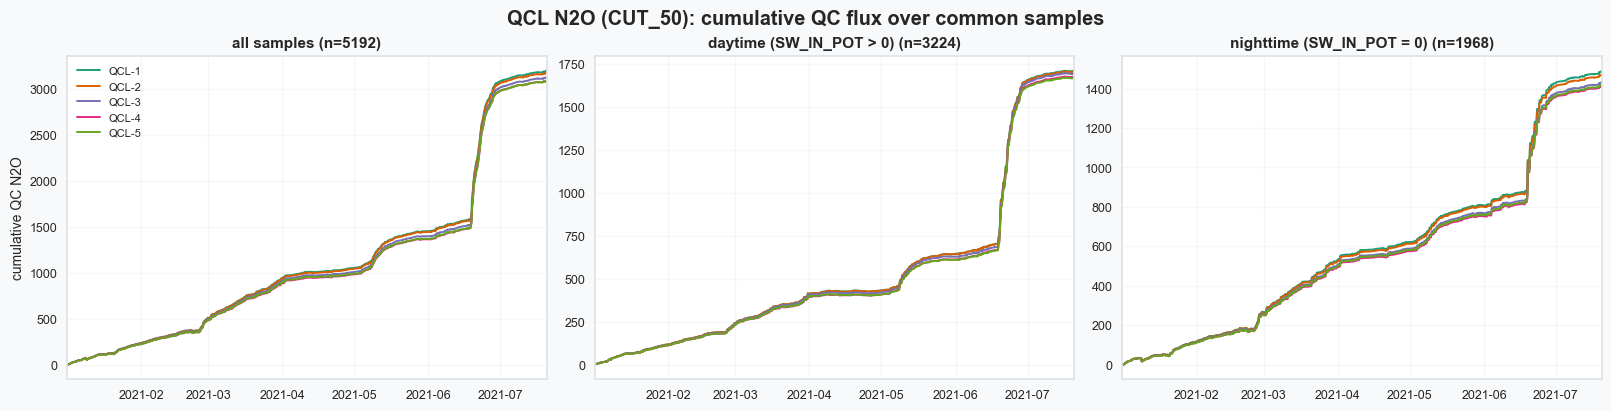

Saved ..\figures\06_cumulative_cut_50_qcl_ch4.png


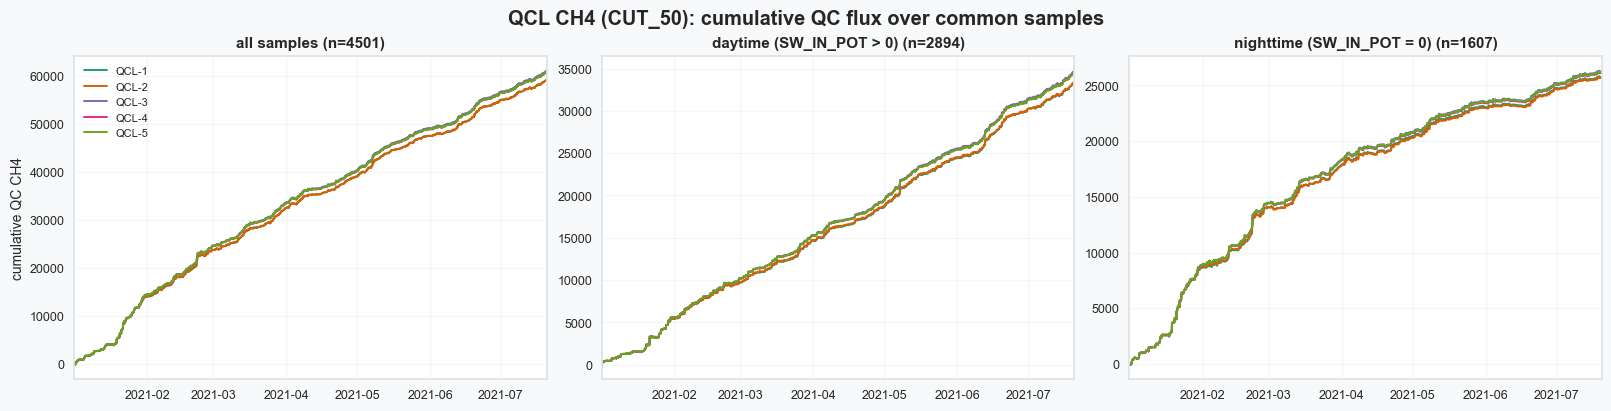

Saved ..\figures\06_cumulative_cut_50_lgr_n2o.png


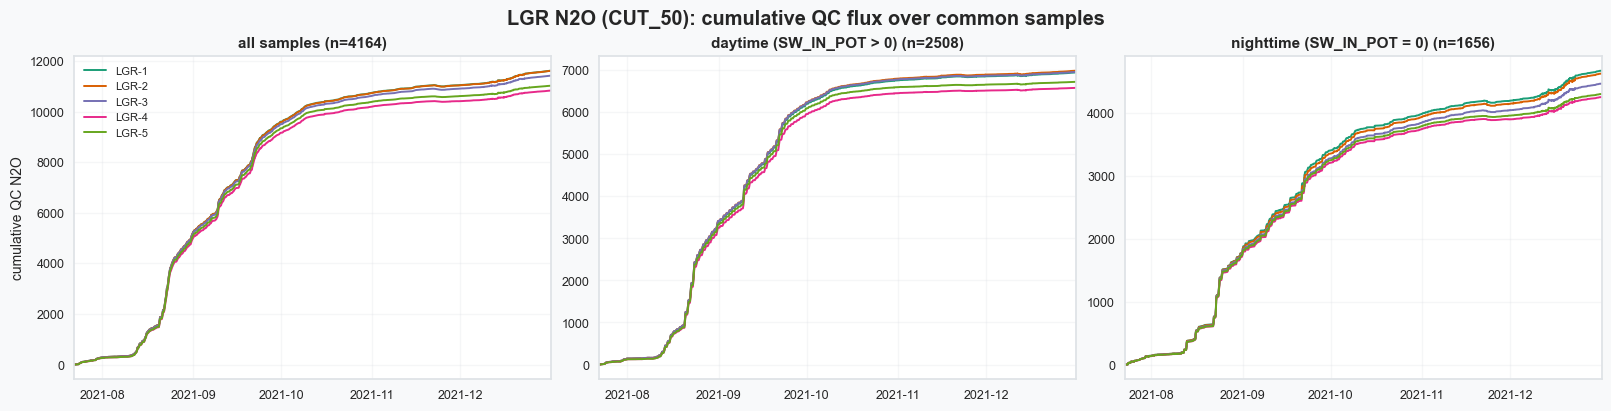

Saved ..\figures\06_cumulative_cut_50_lgr_ch4.png


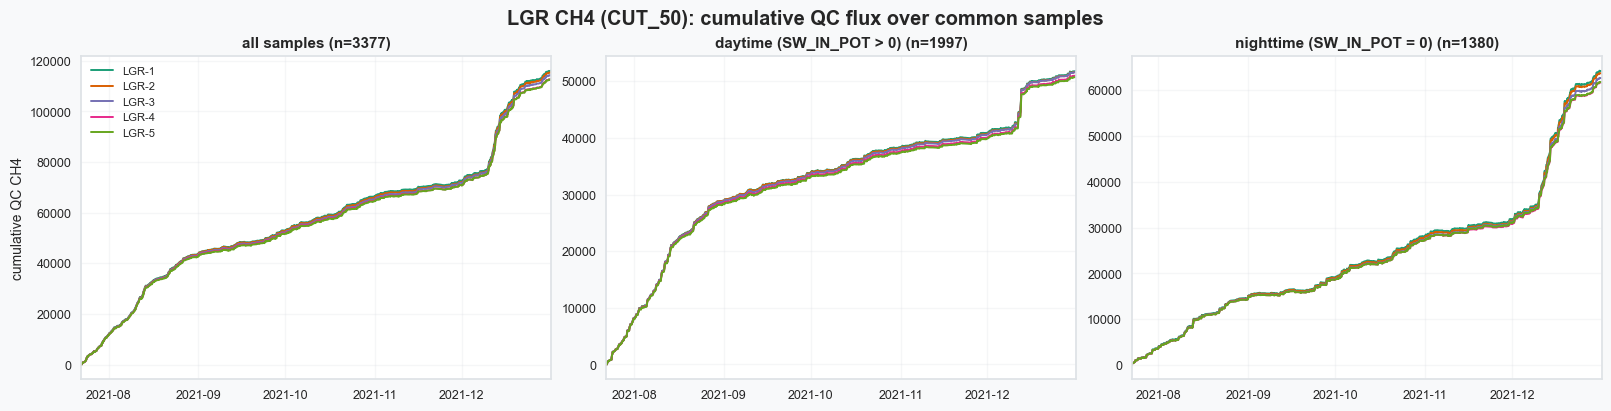

In [5]:
VAR_COLORS = {"-1": "#1b9e77", "-2": "#d95f02", "-3": "#7570b3",
              "-4": "#e7298a", "-5": "#66a61e"}


def draw_cumulative(ax, frame, title):
    """Plot the running sum of each variant's flux on `ax`."""
    cum = frame.cumsum()
    for code in frame.columns:
        suffix = "-" + code.split("-", 1)[1]
        ax.plot(cum.index, cum[code], lw=1.4, color=VAR_COLORS.get(suffix), label=code)
    if len(cum.index):
        ax.set_xlim(cum.index.min(), cum.index.max())
    ax.set_title(f"{title} (n={frame.shape[0]})", fontweight="bold")
    ax.grid(True, alpha=0.3)


for analyzer, info in ANALYZERS.items():
    columns = info["flux_variants"] + [info["pwb"]]
    sw = swin[columns[0]]  # identical across variants
    for gas in GASES:
        # Align the variants and keep only timestamps where all have a QC flux.
        frame = pd.DataFrame({code: qcflux[(code, gas)] for code in columns})
        common = frame.dropna(how="any")
        sw_common = sw.reindex(common.index)
        panels = [
            ("all samples", common),
            ("daytime (SW_IN_POT > 0)", common[sw_common > 0]),
            ("nighttime (SW_IN_POT = 0)", common[sw_common == 0]),
        ]
        fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
        for ax, (title, fr) in zip(axes, panels):
            draw_cumulative(ax, fr, title)
        axes[0].set_ylabel(f"cumulative QC {gas}")
        axes[0].legend(fontsize=8)
        fig.suptitle(f"{analyzer} {gas} ({USTAR_SCENARIO}): cumulative QC flux "
                     f"over common samples", fontweight="bold")
        out = (FIGDIR /
               f"06_cumulative_{USTAR_SCENARIO.lower()}_{analyzer.lower()}_{gas.lower()}.png")
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print(f"Saved {out}")
        plt.show()

## Runtime

In [6]:
NB_END = datetime.now()
print(f"Start:    {NB_START:%Y-%m-%d %H:%M:%S}")
print(f"End:      {NB_END:%Y-%m-%d %H:%M:%S}")
print(f"Runtime:  {NB_END - NB_START}")

Start:    2026-06-24 15:20:03
End:      2026-06-24 15:20:28
Runtime:  0:00:25.710113
